<a href="https://colab.research.google.com/github/H-TAMURA-9250/EU_M_Math-Repository/blob/main/Chap3_Cm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#3-1
from pandas.io.parsers.readers import read_csv
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
sns.set()
%matplotlib inline

#小数第3位まで表示
%precision 3

#webからデータを取得したり，zipファイルを扱うためのライブラリ
import requests, zipfile
from io import StringIO
import io

ur1 = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'



In [6]:
import requests
from io import StringIO

# Fetch the content of the CSV using requests, bypassing SSL verification
response = requests.get(ur1, verify=False)
response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

# Read the content into a pandas DataFrame using StringIO
df = pd.read_csv(StringIO(response.text), sep=';')

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'archive.ics.uci.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [7]:
display(df.describe())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [8]:
# 新しいURLを定義
url_student = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00356/student.zip'

# zipファイルをダウンロード
response_student = requests.get(url_student, verify=False)
response_student.raise_for_status()

# zipファイルをインメモリで開く
with zipfile.ZipFile(io.BytesIO(response_student.content)) as zf:
    # student-mat.csvを読み込む
    with zf.open('student-mat.csv') as f:
        df_student = pd.read_csv(f, sep=';')

display(df_student.head())

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'archive.ics.uci.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [9]:
# 性別とG1の列を選択
df_math_grades = df_student[['sex', 'G1']].copy()

# 性別でグループ化し、G1で昇順にソート
df_math_grades_sorted = df_math_grades.sort_values(by=['sex', 'G1']).reset_index(drop=True)

# 男女別にローレンツ曲線のデータを計算
lorenz_data = {}
for sex_val in df_math_grades_sorted['sex'].unique():
    subset = df_math_grades_sorted[df_math_grades_sorted['sex'] == sex_val].copy()

    # 人数の累積比率（横軸）
    subset['cumulative_students'] = (subset.index - subset.index.min() + 1) / len(subset)

    # G1の累積比率（縦軸）
    total_g1 = subset['G1'].sum()
    subset['cumulative_g1'] = subset['G1'].cumsum() / total_g1

    lorenz_data[sex_val] = subset

# 結果の一部を表示して確認
print("女性のローレンツ曲線データの一部:")
display(lorenz_data['F'].head())
print("男性のローレンツ曲線データの一部:")
display(lorenz_data['M'].head())

女性のローレンツ曲線データの一部:


,sex,G1,cumulative_students,cumulative_g1
0,F,4,0.004808,0.001811
1,F,5,0.009615,0.004074
2,F,5,0.014423,0.006338
3,F,5,0.019231,0.008601
4,F,6,0.024038,0.011317


男性のローレンツ曲線データの一部:


,sex,G1,cumulative_students,cumulative_g1
208,M,3,0.005348,0.001429
209,M,5,0.010695,0.003810
210,M,5,0.016043,0.006190
211,M,5,0.021390,0.008571
212,M,5,0.026738,0.010952


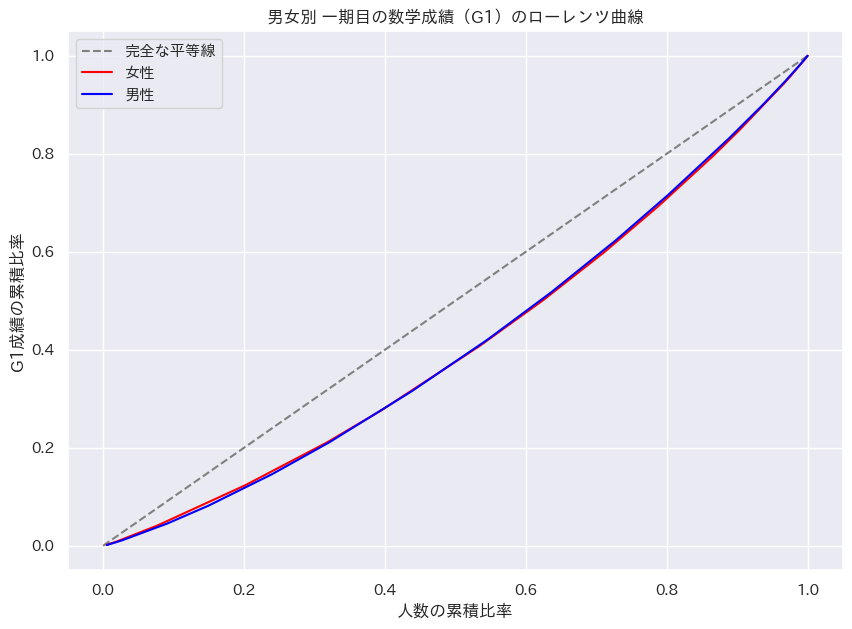

In [14]:
plt.figure(figsize=(10, 7))

# 完全な平等線（対角線）
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='完全な平等線')

# 男女別のローレンツ曲線をプロット
colors = {'F': 'red', 'M': 'blue'}
labels = {'F': '女性', 'M': '男性'}

for sex_val, data in lorenz_data.items():
    plt.plot(data['cumulative_students'], data['cumulative_g1'], color=colors[sex_val], label=f'{labels[sex_val]}')

plt.title('男女別 一期目の数学成績（G1）のローレンツ曲線')
plt.xlabel('人数の累積比率')
plt.ylabel('G1成績の累積比率')
plt.grid(True)
plt.legend()
plt.show()

In [16]:
#3-2
def calculate_gini(cumulative_x, cumulative_y):
    # ジニ係数を計算する関数
    # cumulative_x: 人数の累積比率 (0から1まで)
    # cumulative_y: G1成績の累積比率 (0から1まで)

    # ローレンツ曲線の下の面積を台形公式で計算
    area_under_lorenz_curve = np.trapz(cumulative_y, cumulative_x)

    # ジニ係数 = 1 - 2 * (ローレンツ曲線の下の面積)
    gini_coefficient = 1 - 2 * area_under_lorenz_curve
    return gini_coefficient

gini_coefficients = {}
for sex_val, data in lorenz_data.items():
    cumulative_students = data['cumulative_students']
    cumulative_g1 = data['cumulative_g1']
    gini = calculate_gini(cumulative_students, cumulative_g1)
    gini_coefficients[labels[sex_val]] = gini

for sex_label, gini_val in gini_coefficients.items():
    print(f"{sex_label} の G1成績に関するジニ係数: {gini_val:.4f}")


女性 の G1成績に関するジニ係数: 0.1724
男性 の G1成績に関するジニ係数: 0.1720


/tmp/ipykernel_4848/553020224.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area_under_lorenz_curve = np.trapz(cumulative_y, cumulative_x)
